
#Perceptrón: algoritmo implementado y por qué funciona :)




## La idea detrás del modelo

El perceptrón es, probablemente, el clasificador lineal más sencillo que existe. Su tarea es encontrar una línea (o, en dimensiones más altas, un hiperplano) capaz de separar dos grupos de puntos etiquetados como -1 y +1.

Ese hiperplano queda definido por dos elementos: un vector de pesos **w**, que indica su orientación, y un sesgo **b**, que indica su desplazamiento respecto al origen. Una vez entrenado, clasificar un punto nuevo es tan simple como mirar de qué lado de esa línea cae:

$$
predicion(x) = signo(w · x + b)
$$

## El proceso de entrenamiento, paso a paso

El algoritmo arranca desde cero: **w = 0** y **b = 0**, sin ningún conocimiento previo. A partir de ahí, va refinando esos valores iterando varias veces (épocas) sobre el conjunto de entrenamiento.

En cada vuelta, revisa uno por uno los ejemplos $(x_i, y_i)$ y se pregunta: *¿este punto está del lado correcto de la frontera?* La respuesta se obtiene evaluando:

$$
y_i \cdot (w \cdot x_i + b) \leq 0
$$

Si esta desigualdad se cumple, significa que el modelo se equivocó, y corrige inmediatamente sus parámetros:

$$
w = w + \text{tasa_aprendizaje} \cdot y_i \cdot x_i
$$

$$
b = b + \text{tasa_aprendizaje} \cdot y_i
$$

El ciclo continúa hasta que ya no haya errores que corregir, o hasta agotar el número máximo de épocas permitido.

## La intuición matemática: ¿por qué esto realmente funciona?

El término $y_i \cdot (w \cdot x_i + b)$ es, en el fondo, un indicador de confianza: cuanto más positivo, más "segura" y correcta es la clasificación de ese punto; si es negativo o cero, el modelo está fallando. A este valor se le suele llamar el **margen** de la predicción.

Lo interesante es lo que ocurre justo después de una corrección. Si un punto estaba mal clasificado y aplicamos la actualización $w \leftarrow w + \text{tasa_aprendizaje} \cdot y_i \cdot x_i$, el margen de ese mismo punto mejora de inmediato:

$$
\begin{aligned}
y_i \left( (w + \mathrm{ta}\, y_i x_i) \cdot x_i + b \right)
&= y_i (w \cdot x_i + b) + \mathrm{ta}\, y_i^2 \|x_i\|^2 \\
&= y_i (w \cdot x_i + b) + \mathrm{ta}\, \|x_i\|^2
\qquad \text{(porque } y_i^2 = 1\text{)}
\end{aligned}
$$

Dicho de otro modo: cada ajuste suma una cantidad positiva ($\text{ta} \cdot \|x_i\|^2 \geq 0$) al margen del punto que falló, empujando la frontera de decisión exactamente en la dirección que necesita para clasificarlo bien. Visualmente, el vector **w** gira acercándose a $x_i$ (cuando $y_i = +1$) o alejándose de él (cuando $y_i = -1$).

## ¿Y esto siempre termina bien?

Aquí es donde entra un resultado clásico, el **teorema de convergencia del perceptrón**: si los datos son linealmente separables —es decir, si existe un hiperplano capaz de separarlos con un margen $\gamma > 0$—, entonces el algoritmo cometerá, como máximo, $(R/\gamma)^2$ errores en total, siendo $R$ la norma máxima entre todos los puntos. En otras palabras: el entrenamiento tiene garantizado terminar, en un número finito de pasos, sin quedar atrapado en un ciclo eterno.

Ahora bien, si los datos **no** son linealmente separables, esa garantía desaparece: el perceptrón seguirá corrigiendo errores indefinidamente, sin llegar nunca a una solución perfecta. Por eso, en la práctica, siempre se fija un límite de épocas como red de seguridad.

Convergió después de 2 época(s). Los datos son linealmente separables.
Pesos finales: [2.24377366 1.16801272]
Sesgo final: 1.0
Precisión de entrenamiento: 100.0%


Gráfico guardado en resultado_perceptron.png


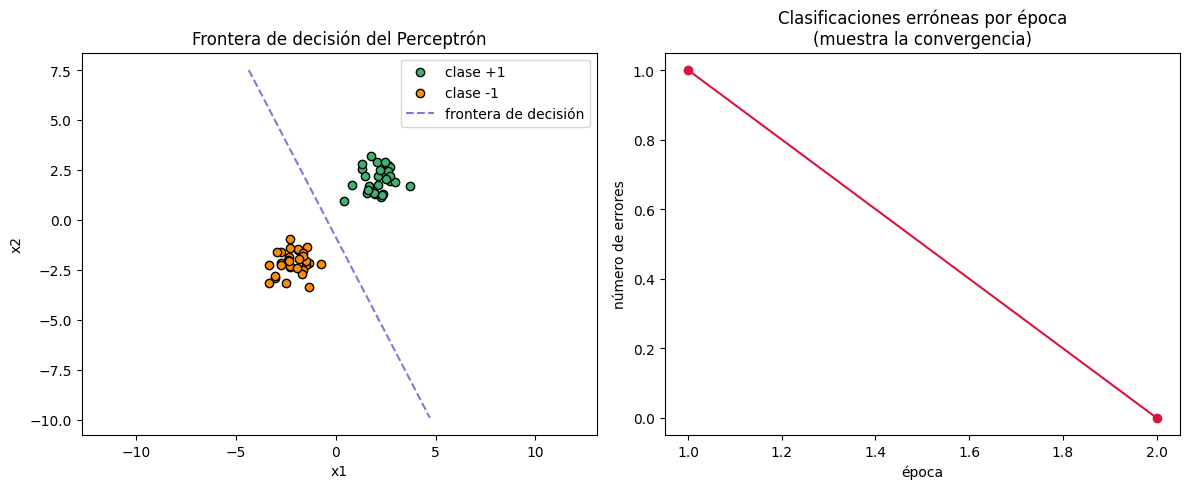

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, tasa_aprendizaje: float = 1.0, n_epocas: int = 100):
        self.tasa_aprendizaje = tasa_aprendizaje
        self.n_epocas = n_epocas
        self.pesos = None      # vector de pesos
        self.sesgo = 0.0        # sesgo (bias)
        self.errores_por_epoca = []  # para seguir la convergencia

    def entrada_neta(self, X):
        """Calcula w . x + b para cada fila de X."""
        return X @ self.pesos + self.sesgo

    def predecir(self, X):
        """Devuelve predicciones de clase -1 / +1."""
        return np.where(self.entrada_neta(X) >= 0, 1, -1)

    def entrenar(self, X, y):
        """
        Entrena usando la regla de actualización clásica del perceptrón.
        X: (n_muestras, n_caracteristicas)
        y: (n_muestras,) con valores en {-1, +1}
        """
        n_muestras, n_caracteristicas = X.shape
        self.pesos = np.zeros(n_caracteristicas)
        self.sesgo = 0.0

        for epoca in range(self.n_epocas):
            errores = 0
            for x_i, y_i in zip(X, y):
                # Condición de clasificación errónea: y_i*(w.x_i + b) <= 0
                margen = y_i * (np.dot(self.pesos, x_i) + self.sesgo)
                if margen <= 0:
                    self.pesos += self.tasa_aprendizaje * y_i * x_i
                    self.sesgo += self.tasa_aprendizaje * y_i
                    errores += 1
            self.errores_por_epoca.append(errores)

            if errores == 0:
                print(f"Convergió después de {epoca + 1} época(s). "
                      f"Los datos son linealmente separables.")
                break
        else:
            print(f"Detenido después de {self.n_epocas} épocas "
                  f"(puede que no sean linealmente separables).")

        return self


def crear_datos_demo(n_por_clase: int = 30, semilla: int = 42):
    """Crea dos nubes gaussianas 2D linealmente separables, etiquetadas -1/+1."""
    rng = np.random.default_rng(semilla)
    clase_pos = rng.normal(loc=[2, 2], scale=0.8, size=(n_por_clase, 2))
    clase_neg = rng.normal(loc=[-2, -2], scale=0.8, size=(n_por_clase, 2))
    X = np.vstack([clase_pos, clase_neg])
    y = np.hstack([np.ones(n_por_clase), -np.ones(n_por_clase)])
    return X, y


def graficar_resultado(X, y, modelo: Perceptron):
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

    # --- izquierda: datos + frontera de decisión ---
    ax = ejes[0]
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="mediumseagreen",
               label="clase +1", edgecolor="black")
    ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color="darkorange",
               label="clase -1", edgecolor="black")

    # frontera de decisión: w0*x1 + w1*x2 + b = 0  ->  x2 = -(w0*x1 + b)/w1
    x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    if modelo.pesos[1] != 0:
        y_vals = -(modelo.pesos[0] * x_vals + modelo.sesgo) / modelo.pesos[1]
        ax.plot(x_vals, y_vals, color="mediumpurple", linestyle="--",
                label="frontera de decisión")

    ax.set_title("Frontera de decisión del Perceptrón")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.axis("equal")

    # --- derecha: errores por época (muestra la convergencia) ---
    ax2 = ejes[1]
    ax2.plot(range(1, len(modelo.errores_por_epoca) + 1),
              modelo.errores_por_epoca, marker="o", color="crimson")
    ax2.set_title("Clasificaciones erróneas por época\n(muestra la convergencia)")
    ax2.set_xlabel("época")
    ax2.set_ylabel("número de errores")

    plt.tight_layout()
    plt.savefig("resultado_perceptron.png", dpi=150)
    print("Gráfico guardado en resultado_perceptron.png")


if __name__ == "__main__":
    X, y = crear_datos_demo()

    modelo = Perceptron(tasa_aprendizaje=1.0, n_epocas=50)
    modelo.entrenar(X, y)

    print("Pesos finales:", modelo.pesos)
    print("Sesgo final:", modelo.sesgo)

    predicciones = modelo.predecir(X)
    precision = np.mean(predicciones == y)
    print(f"Precisión de entrenamiento: {precision * 100:.1f}%")

    graficar_resultado(X, y, modelo)
